**1. Unzipping the folder:**

In [1]:
# This unzips your data into a folder named 'dataset'
!unzip -q hardware_dataset3.zip -d dataset/
print("Dataset unzipped successfully!")

Dataset unzipped successfully!


**2. Pre-Processing:**

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Advanced Augmentation to tackle the GPU variety problem
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,           # More tilt
    width_shift_range=0.2,       # Move left/right
    height_shift_range=0.2,      # Move up/down
    shear_range=0.2,             # Geometric distortion
    zoom_range=0.2,              # Zoom in/out
    brightness_range=[0.8, 1.2],  # Change lighting
    horizontal_flip=True,
    fill_mode='nearest',         # Fills empty pixels created by shifts
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    'dataset/hardware_dataset3', target_size=(224, 224), batch_size=10,
    class_mode='categorical', subset='training'
)

test_data = datagen.flow_from_directory(
    'dataset/hardware_dataset3', target_size=(224, 224), batch_size=10,
    class_mode='categorical', subset='validation'
)

Found 107 images belonging to 5 classes.
Found 24 images belonging to 5 classes.


**3. Downloading MobileNetV2 base model:**

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Fine-Tuning: Only the last 10 layers are allowed to learn
base_model.trainable = True
for layer in base_model.layers[:144]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'), # Increased neurons for more 'memory'
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Version 3 Architecture Ready.")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Version 3 Architecture Ready.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 1,061,701 (4.05 MB)

 Non-trainable params: 1,525,504 (5.82 MB)

**4. Training and testing through MobileNetV2:**

In [4]:
# Callback: Slows down if the model gets stuck
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001
)

print("Starting Version 3 Training (The Final Squeeze)...")
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=25, # More epochs to allow the scheduler to work
    callbacks=[lr_reducer]
)

Starting Version 3 Training (The Final Squeeze)...
Epoch 1/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.2430 - loss: 1.8687 - val_accuracy: 0.2917 - val_loss: 1.4298 - learning_rate: 1.0000e-04
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.5327 - loss: 1.1684 - val_accuracy: 0.6250 - val_loss: 0.9775 - learning_rate: 1.0000e-04
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.7196 - loss: 0.8142 - val_accuracy: 0.7500 - val_loss: 0.6489 - learning_rate: 1.0000e-04
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.7944 - loss: 0.5907 - val_accuracy: 0.7083 - val_loss: 0.7379 - learning_rate: 1.0000e-04
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.8224 - loss: 0.5187 - val_accuracy: 0.7500 - val_loss: 0.6260 - learning_rate: 1.0000e-04
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.8598 - loss: 0.4450 - val_accuracy: 0.8333 - val_loss: 0.4913 - learning_rate: 1.0000e-04
Epoch 7/25
11/1

**5. Evaluation Metrics:**

Found 24 images belonging to 5 classes.
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step

CLASS NAME      | PRECISION  | RECALL     | F1-SCORE   | SPECIFICITY
---------------------------------------------------------------------------
GPU             | 1.0000     | 1.0000     | 1.0000     | 1.0000    
Hard Disk       | 0.8000     | 1.0000     | 0.8889     | 0.9500    
Motherboard     | 0.7500     | 0.7500     | 0.7500     | 0.9500    
Processor       | 1.0000     | 0.6667     | 0.8000     | 1.0000    
RAM             | 0.8000     | 1.0000     | 0.8889     | 0.9500    
OVERALL METRICS | Accuracy: 0.8750 | Log Loss: 0.2492



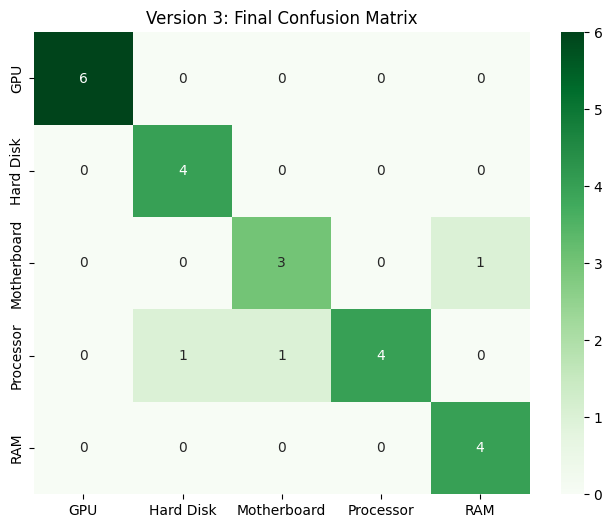

In [5]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, log_loss
import matplotlib.pyplot as plt
import seaborn as sns

test_data_eval = datagen.flow_from_directory(
    'dataset/hardware_dataset3', target_size=(224, 224), batch_size=10,
    class_mode='categorical', subset='validation', shuffle=False
)

predictions = model.predict(test_data_eval)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data_eval.classes
class_names = list(test_data_eval.class_indices.keys())

model_log_loss = log_loss(true_classes, predictions)
report = classification_report(true_classes, predicted_classes, target_names=class_names, output_dict=True)
cm = confusion_matrix(true_classes, predicted_classes)

print("\n" + "="*75)
print(f"{'CLASS NAME':<15} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10} | {'SPECIFICITY':<10}")
print("-" * 75)

for i, class_name in enumerate(class_names):
    tp, fp, fn, tn = cm[i, i], (cm[:, i].sum()-cm[i, i]), (cm[i, :].sum()-cm[i, i]), (cm.sum()-(cm[:, i].sum()+cm[i, :].sum()-cm[i, i]))
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{class_name:<15} | {report[class_name]['precision']:<10.4f} | {report[class_name]['recall']:<10.4f} | {report[class_name]['f1-score']:<10.4f} | {specificity:<10.4f}")

print("="*75)
print(f"OVERALL METRICS | Accuracy: {report['accuracy']:.4f} | Log Loss: {model_log_loss:.4f}")
print("="*75 + "\n")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Version 3: Final Confusion Matrix')
plt.show()

**6. Saving the trained model and prediction:**

Final Production Model Saved!

--- UPLOAD TEST IMAGE ---


Saving download (3).jpg to download (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

******************************
 PREDICTION : Motherboard
 CONFIDENCE : 99.72%
******************************



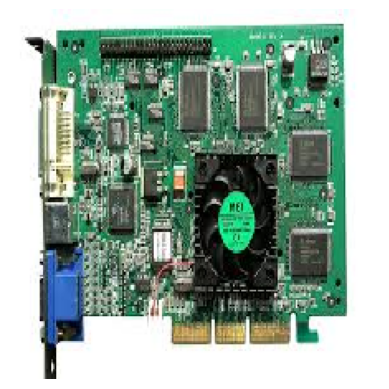

In [8]:
from tensorflow.keras.preprocessing import image
from google.colab import files

model.save('final_hardware_model_v3.keras')
print("Final Production Model Saved!")

# Live Demo
print("\n--- UPLOAD TEST IMAGE ---")
uploaded = files.upload()

for filename in uploaded.keys():
    img = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction_probs = model.predict(img_array)
    winning_index = np.argmax(prediction_probs)

    print("\n" + "*"*30)
    print(f" PREDICTION : {class_names[winning_index]}")
    print(f" CONFIDENCE : {np.max(prediction_probs)*100:.2f}%")
    print("*"*30 + "\n")
    plt.imshow(img); plt.axis('off'); plt.show()